In [1]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [2]:
cell_tag = client.materialize.query_table('spinalcord_neuron_clusters_2')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [3]:
set(cell_tag['tag'])

{'adltmr_module',
 'cltmr_module',
 'noci_module',
 'np_module',
 'p1',
 'p2_cold',
 'p2_noci',
 'p2_poly',
 'r',
 'v1',
 'v2'}

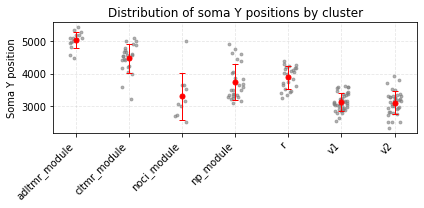

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------- config -------------------
cluster_order = [
    'adltmr_module',
    'cltmr_module',
    'noci_module',
    'np_module',
    'r',
    'v1',
    'v2',
]

# extract Y positions
cell_tag = cell_tag.copy()
cell_tag['y'] = cell_tag['pt_position'].apply(lambda p: p[1] if isinstance(p, (list, np.ndarray)) else np.nan)

# keep only target clusters
subset = cell_tag[cell_tag['tag'].isin(cluster_order)]

# prepare data grouped by cluster
grouped = subset.groupby('tag')['y']

means = grouped.mean()
stds = grouped.std()

# ------------------- plot -------------------
fig, ax = plt.subplots(figsize=(6, 3))

# x positions for clusters
x_pos = np.arange(len(cluster_order))

# plot individual points
for i, tag in enumerate(cluster_order):
    yvals = subset.loc[subset['tag'] == tag, 'y']
    ax.scatter(
        np.full_like(yvals, i, dtype=float) + np.random.uniform(-0.15, 0.15, size=len(yvals)),
        yvals,
        color='gray',
        alpha=0.6,
        s=8,
        zorder=1,
    )

# plot mean ± SD
ax.errorbar(
    x_pos,
    means[cluster_order],
    yerr=stds[cluster_order],
    fmt='o',
    color='red',
    ecolor='red',
    elinewidth=1,
    capsize=3,
    markersize=5,
    zorder=2,
)

# labels and style
ax.set_xticks(x_pos)
ax.set_xticklabels(cluster_order, rotation=45, ha='right')
ax.set_ylabel('Soma Y position')
ax.set_title('Distribution of soma Y positions by cluster')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# filter for noci_module
noci_coords = cell_tag.loc[cell_tag['tag'] == 'noci_module', ['pt_root_id', 'pt_position']]

# show them
print(noci_coords)


            pt_root_id          pt_position
47  720575940941106028  [29347, 3155, 1813]
48  720575940922949405  [23048, 3069, 1851]
49  720575940899282056  [29678, 3655, 1401]
50  720575940917429907  [26042, 2994, 1393]
51  720575940890134196  [23025, 5024, 2001]
52  720575940888793434  [23420, 3524, 1951]
53  720575940920932008  [26733, 3643, 2051]
54  720575940909430811  [24889, 2507, 2057]
55  720575940881936635  [23672, 2720, 1354]
56  720575940919071815  [27063, 2677, 1351]


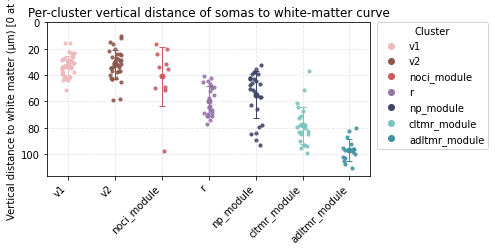

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# ------------------- config -------------------
x_res = 32   # nm/px
y_res = 32   # nm/px
y_offset_um = (2300 * y_res) / 1000.0  # 2300 px → µm offset

# White-matter curve: FIRST curve control points (in pixels)
wm_ctrl_px = np.array([[6896, 2306],
                       [25227, 2000],
                       [46840, 3257]], dtype=float)

# Clusters to include (x-axis order)
cluster_order = [
    'v1',
    'v2',
    'noci_module',
    'r',
    'np_module',
    'cltmr_module',
    'adltmr_module',
  
    

]

# Distinct colors per cluster (RGB in 0–255)
cluster_colors_255 = {
    'adltmr_module': (64, 145, 162),  
    'cltmr_module' : (124, 196, 190),  
    'noci_module'  : ( 202, 91, 96),  
    'np_module'    : (65, 69, 103),  
    'r'            : ( 148, 116, 166),  
    'v1'           : (238, 185, 187),  
    'v2'           : (140,  86,  75),  
}

# Convert to Matplotlib-friendly 0–1 floats
cluster_colors = {k: tuple(c/255.0 for c in rgb) for k, rgb in cluster_colors_255.items()}


# ------------------- helpers -------------------
def to_um_with_yoffset_xy(px, py):
    x_um = (px * x_res) / 1000.0
    y_um = (py * y_res) / 1000.0 - y_offset_um
    return x_um, y_um

def extract_xy_um_from_celltag(df):
    x_list, y_list, good_idx = [], [], []
    for idx, p in zip(df.index, df['pt_position'].values):
        if isinstance(p, (list, tuple, np.ndarray)) and len(p) >= 2:
            x_um, y_um = to_um_with_yoffset_xy(p[0], p[1])
            x_list.append(x_um); y_list.append(y_um); good_idx.append(idx)
    return np.array(good_idx), np.array(x_list, float), np.array(y_list, float)

def build_wm_spline_um(ctrl_px):
    scaled = ctrl_px * np.array([x_res, y_res]) / 1000.0  # -> µm
    x = scaled[:, 0]
    y = scaled[:, 1] - y_offset_um
    spl = make_interp_spline(x, y, k=2)  # match process_curve (quadratic)
    try:
        spl.extrapolate = True
    except Exception:
        pass
    xmin, xmax = spl.t[2], spl.t[-3]  # valid domain for k=2
    return spl, xmin, xmax

# ------------------- compute vertical distances -------------------
df = cell_tag.loc[cell_tag['tag'].isin(cluster_order)].copy()

kept_idx, x_um_all, y_um_all = extract_xy_um_from_celltag(df)
df = df.loc[kept_idx].copy()
df['x_um'] = x_um_all
df['y_um'] = y_um_all

wm_spline, xmin, xmax = build_wm_spline_um(wm_ctrl_px)
x_eval = np.clip(df['x_um'].to_numpy(float), xmin, xmax)
y_curve = wm_spline(x_eval)

# Absolute vertical distance (µm) to the curve: |y_point - f(x_point)|
df['dist_to_white_matter_um'] = np.abs(df['y_um'].to_numpy(float) - y_curve)

# ------------------- plot (reversed Y: 0 at top, increases downward) -------------------
fig, ax = plt.subplots(figsize=(7.0, 3.6))
x_positions = np.arange(len(cluster_order))
jitter = 0.14

means, stds = [], []

# points
for i, tag in enumerate(cluster_order):
    vals = df.loc[df['tag'] == tag, 'dist_to_white_matter_um'].to_numpy()
    xi = i + np.random.uniform(-jitter, jitter, size=len(vals))
    ax.scatter(xi, vals, s=10, alpha=0.85, color=cluster_colors[tag], zorder=1)
    means.append(np.nanmean(vals) if len(vals) else np.nan)
    stds.append(np.nanstd(vals) if len(vals) else np.nan)

# per-cluster mean ± SD in matching color
for i, tag in enumerate(cluster_order):
    m, s = means[i], stds[i]
    if np.isfinite(m):
        ax.errorbar(i, m, yerr=s, fmt='o',
                    color=cluster_colors[tag], ecolor=cluster_colors[tag],
                    elinewidth=1, capsize=3, markersize=5, zorder=2)

# x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(cluster_order, rotation=45, ha='right')

# Y axis: 0 at top, increasing to bottom
ymax = float(np.nanmax(df['dist_to_white_matter_um'])) if len(df) else 1.0
ax.set_ylim(0, ymax * 1.05)
ax.invert_yaxis()  # <-- reverse so 0 is at the top

ax.set_ylabel('Vertical distance to white matter (µm) [0 at top]')
ax.set_title('Per-cluster vertical distance of somas to white-matter curve')
ax.grid(True, linestyle='--', alpha=0.3)

# legend
handles = [plt.Line2D([0],[0], marker='o', linestyle='None',
                      color=cluster_colors[tag], label=tag, markersize=6)
           for tag in cluster_order]
ax.legend(handles=handles, title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


In [7]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def plot_violin_consistent(
    data_arrays,            # list[np.ndarray]: one 1D array per group
    labels,                 # list[str]: same length as data_arrays
    colors,                 # list[matplotlib-colors]: same length as data_arrays
    *,
    fig_size_cm=(6.0, 6.0),
    invert_y=False,
    y_lim=None,             # (ymin, ymax) or None
    jitter=0.15,
    dot_size=2,
    dot_alpha=0.3,
    violin_alpha=0.65,
    outline_color="black",
    outline_width=0.5,
    mean_halfwidth=0.18,    # x-units
    xtick_rotation=-50,
    xtick_fontsize=7,
    ytick_fontsize=7,
    ylabel=None,
    # fixed subplot margins (use the SAME numbers for every figure you want identical)
    subplot_rect=(0.18, 0.98, 0.30, 0.98),  # (left, right, bottom, top)
    seed=0,
    # saving
    save=False,
    output_dir=".",
    basename=None,
    fmt="svg",
    dpi=300,
    bbox_tight=False        # keep False to avoid re-cropping shifts
):
    """Create a consistent violin plot and optionally save it.
    Returns (fig, ax, save_path). save_path is None if save=False.
    """
    # filter out empties (violinplot cannot draw them)
    kept = [len(a) > 0 for a in data_arrays]
    data   = [a for a, k in zip(data_arrays, kept) if k]
    labs   = [l for l, k in zip(labels, kept) if k]
    colrs  = [c for c, k in zip(colors, kept) if k]

    # figure + axis
    cm_to_in = 1/2.54
    fig = plt.figure(figsize=(fig_size_cm[0]*cm_to_in, fig_size_cm[1]*cm_to_in))
    ax = fig.add_subplot(111)

    # 1-based x positions; lock bounds; no auto margins
    N = len(data)
    x = np.arange(1, N+1)

    parts = ax.violinplot(
        data,
        positions=x,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.7
    )
    for body, fc in zip(parts.get("bodies", []), colrs):
        body.set_facecolor(fc)
        body.set_edgecolor(outline_color)
        body.set_linewidth(outline_width)
        body.set_alpha(violin_alpha)

    # points
    rng = np.random.default_rng(seed)
    for i, arr in enumerate(data):
        xi = x[i] + rng.uniform(-jitter, jitter, size=len(arr))
        ax.scatter(
            xi, arr,
            s=dot_size, marker="o",
            facecolors="black", edgecolors="black", linewidths=0,
            alpha=dot_alpha, zorder=2.6
        )

    # mean bars
    for i, arr in enumerate(data):
        m = float(np.nanmean(arr)) if len(arr) else np.nan
        if np.isfinite(m):
            ax.hlines(m, x[i]-mean_halfwidth, x[i]+mean_halfwidth,
                      colors=outline_color, linewidth=outline_width, zorder=4)

    # axis box/limits
    ax.set_xlim(0.5, N+0.5)
    ax.margins(x=0, y=0)
    if y_lim is not None:
        ax.set_ylim(*y_lim)
    if invert_y:
        ax.invert_yaxis()

    # ticks/labels
    ax.set_xticks(x)
    ax.set_xticklabels(labs, rotation=xtick_rotation, ha="left", fontsize=xtick_fontsize)
    ax.tick_params(axis='y', labelsize=ytick_fontsize)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=ytick_fontsize)

    # cosmetics
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(axis='both', width=0.5)

    # fixed subplot margins (identical between figures)
    fig.subplots_adjust(left=subplot_rect[0], right=subplot_rect[1],
                        bottom=subplot_rect[2], top=subplot_rect[3])

    # save (inside the function)
    save_path = None
    if save:
        os.makedirs(output_dir, exist_ok=True)
        if basename is None:
            basename = f"violin_{datetime.now():%Y%m%d-%H%M%S}"
        save_path = os.path.join(output_dir, f"{basename}.{fmt}")
        if bbox_tight:
            fig.savefig(save_path, format=fmt, dpi=dpi, bbox_inches="tight")
        else:
            fig.savefig(save_path, format=fmt, dpi=dpi)

    return fig, ax, save_path


In [9]:
from matplotlib.colors import to_rgb

group_alias = {
    "v1": "Vertical",
    "v2": "Vertical",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "r": "Radial",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

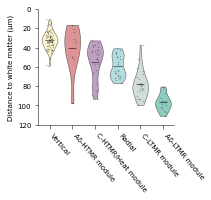

In [10]:
canon = df["tag"].astype(str).map(group_alias)
vals  = df["dist_to_white_matter_um"]
orderA = ["Vertical","Aδ-HTMR module","C-HTMR/Heat module","Radial","C-LTMR module","Aδ-LTMR module"]
paletteA = {
    "Aδ-HTMR module":"#CA5B60",
    "C-HTMR/Heat module":"#9B6DA2",
    "C-LTMR module":"#B9CCC3",
    "Aδ-LTMR module":"#50B19C",
    "Radial":"#8CCBCD",
    "Vertical":"#FCF0B6",
}
colorsA = [to_rgb(paletteA[k]) for k in orderA]
dataA   = [vals.loc[canon==k].dropna().to_numpy() for k in orderA]
labelsA = orderA

figA, axA, pathA = plot_violin_consistent(
    dataA, labelsA, colorsA,
    fig_size_cm=(6.0, 6.0),
    invert_y=True,                 # keep 0 at the top
    y_lim=(0, 120),                # <-- force 0–100 so 0 is shown
    ylabel="Distance to white matter (µm)",
    subplot_rect=(0.18, 0.98, 0.30, 0.98),
    save=False,
    output_dir="/Users/wangchu/connectivity_analysis/sensory_module_figure2",
    basename=f"soma_distance_violin_{datetime.now():%Y%m%d-%H%M%S}",  # <-- removed stray quote
    fmt="svg",
    dpi=600
)


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal

# install if needed:
# !pip install scikit-posthocs
import scikit_posthocs as sp

# -----------------------------
# 1) Build stats dataframe
# -----------------------------
stats_df = pd.DataFrame({
    "group": canon,
    "dist_to_white_matter_um": vals
}).dropna()

orderA = ["Vertical","Aδ-HTMR module","C-HTMR/Heat module","Radial","C-LTMR module","Aδ-LTMR module"]
stats_df = stats_df[stats_df["group"].isin(orderA)].copy()
stats_df["group"] = pd.Categorical(stats_df["group"], categories=orderA, ordered=True)

# -----------------------------
# 2) Per-group summary
# -----------------------------
summary = (
    stats_df.groupby("group")["dist_to_white_matter_um"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n"})
)

q1 = stats_df.groupby("group")["dist_to_white_matter_um"].quantile(0.25)
q3 = stats_df.groupby("group")["dist_to_white_matter_um"].quantile(0.75)
summary["q1"] = q1
summary["q3"] = q3

print("Per-group summary:")
print(summary)

# -----------------------------
# 3) Kruskal-Wallis test
# -----------------------------
group_arrays = [
    stats_df.loc[stats_df["group"] == g, "dist_to_white_matter_um"].to_numpy()
    for g in orderA
]

# keep only non-empty groups
group_arrays_nonempty = [arr for arr in group_arrays if len(arr) > 0]
groups_nonempty = [g for g, arr in zip(orderA, group_arrays) if len(arr) > 0]

H, p_kw = kruskal(*group_arrays_nonempty)

N = len(stats_df)
k = len(groups_nonempty)

# epsilon-squared effect size for Kruskal-Wallis
eps2 = (H - k + 1) / (N - k)

print("\nKruskal-Wallis test:")
print(f"H = {H:.4f}")
print(f"p = {p_kw:.6g}")
print(f"epsilon^2 = {eps2:.4f}")

# -----------------------------
# 4) Dunn post hoc with Holm correction
# -----------------------------
dunn = sp.posthoc_dunn(
    stats_df,
    val_col="dist_to_white_matter_um",
    group_col="group",
    p_adjust="holm"
)

# reorder rows/cols
dunn = dunn.loc[groups_nonempty, groups_nonempty]

print("\nDunn post hoc test (Holm-corrected p-values):")
print(dunn)

# -----------------------------
# 5) Pairwise long-format table
# -----------------------------
pairs = []
for i, g1 in enumerate(groups_nonempty):
    for j, g2 in enumerate(groups_nonempty):
        if j <= i:
            continue
        pval = dunn.loc[g1, g2]
        if pval < 0.001:
            sig = "***"
        elif pval < 0.01:
            sig = "**"
        elif pval < 0.05:
            sig = "*"
        else:
            sig = "ns"
        pairs.append((g1, g2, pval, sig))

pairwise_df = pd.DataFrame(pairs, columns=["group1", "group2", "p_holm", "significance"])
print("\nPairwise comparisons:")
print(pairwise_df.sort_values("p_holm"))

Per-group summary:
                     n       mean     median        std         q1          q3
group                                                                         
Vertical            77  32.376155  33.330068   9.183869  27.200645   37.741495
Aδ-HTMR module      10  40.884317  34.384308  23.520360  25.657162   49.509172
C-HTMR/Heat module  27  54.933687  47.371138  18.162594  42.297935   64.528507
Radial              24  59.485081  63.578600  11.466639  49.120827   69.254680
C-LTMR module       24  78.208863  79.438821  14.448487  71.891049   86.252208
Aδ-LTMR module      15  96.832641  96.841737   8.635242  93.779740  102.516870

Kruskal-Wallis test:
H = 123.4034
p = 5.96499e-25
epsilon^2 = 0.6924

Dunn post hoc test (Holm-corrected p-values):
                        Vertical  Aδ-HTMR module  C-HTMR/Heat module  \
Vertical            1.000000e+00        0.514993            0.000005   
Aδ-HTMR module      5.149933e-01        1.000000            0.208181   
C-HTMR/Heat modu